In [4]:
"""
Example: Using preprocessor.py WITH advanced box scores
This is the RECOMMENDED approach - simpler and more reliable
"""

import sys
sys.path.append('/Users/nicholashorton/Documents/NBA Data')

from preprocessor import ProcessingConfig, DataProcessor
import pandas as pd

# ============================================================================
# STEP 1: Define which columns to process
# ============================================================================

all_processable_columns = [
    # === COUNTING STATS (for cumulative season totals + rolling averages) ===
    'FGM', 'FGA',           # Field goals made/attempted
    'FG3M', 'FG3A',         # Three-pointers made/attempted
    'FTM', 'FTA',           # Free throws made/attempted
    'OREB', 'DREB', 'REB',  # Offensive/Defensive/Total rebounds
    'AST',                  # Assists
    'STL',                  # Steals
    'BLK',                  # Blocks
    'TOV',                  # Turnovers
    'PF',                   # Personal fouls
    'PTS',                  # Points
    'PLUS_MINUS',           # Plus/minus

    # === ADVANCED METRICS (already in advanced box scores!) ===
    'OFF_RATING',           # Points per 100 possessions
    'DEF_RATING',           # Points allowed per 100 possessions
    'NET_RATING',           # Net rating
    'E_OFF_RATING',         # Estimated offensive rating
    'E_DEF_RATING',         # Estimated defensive rating
    'E_NET_RATING',         # Estimated net rating
    'PACE',                 # Pace (possessions per 48 min)
    'E_PACE',               # Estimated pace
    'PACE_PER40',           # Pace per 40 minutes
    'POSS',                 # Total possessions
    'PIE',                  # Player Impact Estimate

    # === PERCENTAGE/RATIO METRICS (already in advanced box scores!) ===
    'AST_PCT',              # Assist percentage
    'AST_TOV',              # Assist to turnover ratio
    'AST_RATIO',            # Assist ratio
    'OREB_PCT',             # Offensive rebound percentage
    'DREB_PCT',             # Defensive rebound percentage
    'REB_PCT',              # Total rebound percentage
    'TM_TOV_PCT',           # Team turnover percentage
    'EFG_PCT',              # Effective field goal percentage
    'TS_PCT',               # True shooting percentage
    'USG_PCT',              # Usage percentage
    'E_USG_PCT'             # Estimated usage percentage
]

# ============================================================================
# STEP 2: Create configuration
# ============================================================================

config = ProcessingConfig(
    all_processable_columns=all_processable_columns,
    rolling_window=5,       # Use 5-game rolling average (adjustable)

    base_columns = [
        'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA',
        'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK',
        'TOV', 'PF', 'PTS', 'PLUS_MINUS',
        'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING',
        'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TOV',
        'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT',
        'E_TM_TOV_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT',
        'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
        'PACE_PER40', 'POSS', 'PIE'
    ],

    # NO DERIVED METRICS NEEDED - we already have them in advanced box scores!
    derived_metrics={},

    # Elo rating parameters (optional to customize)
    initial_elo=1500,
    k_factor=20,
    home_advantage=100,
    elo_width=400
)

# ============================================================================
# STEP 3: Initialize processor and run
# ============================================================================

print("Initializing DataProcessor...")
processor = DataProcessor(config)

print("\nProcessing data...")
print("This will:")
print("  1. Load and merge advanced + traditional box scores")
print("  2. Add home/away context")
print("  3. Calculate rolling (5-game avg) and cumulative stats")
print("  4. Prepare game-level dataset (home vs away)")
print("  5. Calculate Elo ratings")
print("  6. Process player availability")
print("  7. Calculate difference metrics")

df = processor.process(
    advanced_path='/Users/nicholashorton/Documents/NBA Data/Data/Advanced_box_scores_2023.csv',
    traditional_path='/Users/nicholashorton/Documents/NBA Data/Data/traditional_box_scores_2023.csv',
    player_boxscores='/Users/nicholashorton/Documents/NBA Data/Data/player_box_scores_2023.csv'
)

# ============================================================================
# STEP 4: Filter nonsensical columns
# ============================================================================

def filter_nonsensical_columns(df):
    """
    Remove cumulative versions of rate/percentage stats.
    Cumulative only makes sense for counting stats.
    """
    # Define rate/percentage stats that shouldn't have cumulative versions
    rate_stats = [
        'OFF_RATING', 'DEF_RATING', 'NET_RATING',
        'E_OFF_RATING', 'E_DEF_RATING', 'E_NET_RATING',
        'PACE', 'E_PACE', 'PACE_PER40',
        'PIE',
        'AST_PCT', 'AST_TOV', 'AST_RATIO',
        'OREB_PCT', 'DREB_PCT', 'REB_PCT',
        'TM_TOV_PCT',
        'EFG_PCT', 'TS_PCT',
        'USG_PCT', 'E_USG_PCT',
        'FG_PCT', 'FG3_PCT', 'FT_PCT'
    ]

    # Build list of columns to drop
    cols_to_drop = []

    for stat in rate_stats:
        # Drop cumulative versions (both home and away)
        cumulative_home = f'{stat}_cumulative_home'
        cumulative_away = f'{stat}_cumulative_away'

        if cumulative_home in df.columns:
            cols_to_drop.append(cumulative_home)
        if cumulative_away in df.columns:
            cols_to_drop.append(cumulative_away)

    # Drop the columns
    if cols_to_drop:
        print(f"\nFiltering out {len(cols_to_drop)} nonsensical cumulative columns...")
        df = df.drop(columns=cols_to_drop)
        print(f"Examples dropped: {', '.join(cols_to_drop[:5])}{'...' if len(cols_to_drop) > 5 else ''}")

    return df

print("\nFiltering nonsensical columns...")
print("(Removing cumulative versions of rate/percentage stats)")
df = filter_nonsensical_columns(df)

# ============================================================================
# STEP 5: Inspect results
# ============================================================================

print(f"\n{'='*70}")
print(f"Processing complete!")
print(f"{'='*70}")
print(f"Total games processed: {len(df)}")
print(f"Total features: {len(df.columns)}")
print(f"\nFirst few rows:")
print(df.head(2))

print(f"\nColumn categories:")
print(f"  - Elo columns: {len([c for c in df.columns if 'ELO' in c])}")
print(f"  - Rolling columns: {len([c for c in df.columns if '_rolling_' in c])}")
print(f"  - Cumulative columns: {len([c for c in df.columns if '_cumulative_' in c])}")
print(f"  - Missing player columns: {len([c for c in df.columns if 'missing_' in c])}")

# ============================================================================
# STEP 6: Save processed data
# ============================================================================

output_path = 'Data/final_preprocessed_data.csv'
df.to_csv(output_path, index=False)
print(f"\n✅ Saved to: {output_path}")

# ============================================================================
# STEP 7: Quick data quality check
# ============================================================================

print(f"\n{'='*70}")
print("Data Quality Check:")
print(f"{'='*70}")

# Check for missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 10]

if len(high_missing) > 0:
    print(f"\n⚠️  Columns with >10% missing values:")
    for col, pct in high_missing.items():
        print(f"  {col}: {pct:.1f}%")
else:
    print("\n✅ No columns with >10% missing values")

# Check for infinite values
inf_cols = [col for col in df.columns if df[col].dtype in ['float64', 'int64'] and
            (df[col] == float('inf')).any() or (df[col] == float('-inf')).any()]

if len(inf_cols) > 0:
    print(f"\n⚠️  Columns with infinite values: {inf_cols}")
else:
    print("✅ No infinite values detected")

print(f"\n{'='*70}")
print("Ready for modeling!")
print(f"{'='*70}")


Initializing DataProcessor...

Processing data...
This will:
  1. Load and merge advanced + traditional box scores
  2. Add home/away context
  3. Calculate rolling (5-game avg) and cumulative stats
  4. Prepare game-level dataset (home vs away)
  5. Calculate Elo ratings
  6. Process player availability
  7. Calculate difference metrics
Loading and merging data...
Adding context features...

Created 0 cumulative derived metrics:

Created 0 rolling derived metrics:
⚠️  Warning: These columns have issues: []
Preparing game-level dataset...
Calculating Elo ratings...
Calculating derived metrics...

Filtering nonsensical columns...
(Removing cumulative versions of rate/percentage stats)

Filtering out 42 nonsensical cumulative columns...
Examples dropped: OFF_RATING_cumulative_home, OFF_RATING_cumulative_away, DEF_RATING_cumulative_home, DEF_RATING_cumulative_away, NET_RATING_cumulative_home...

Processing complete!
Total games processed: 1230
Total features: 130

First few rows:
     SEA

In [15]:
df

,SEASON_ID_home,TEAM_ID_home,TEAM_NAME_home,GAME_ID,GAME_DATE,WL,FGM_cumulative_home,FGM_rolling_home,FGA_cumulative_home,FGA_rolling_home,...,HOME_ELO_POST,AWAY_ELO_POST,HOME_WIN_PROB,missing_players_home,missing_impact_home,missing_star_home,missing_players_away,missing_impact_away,missing_star_away,WIN
245,22023,1610612743,Denver Nuggets,22300061,2023-10-24,1,NaN,NaN,NaN,NaN,...,1508.638440,1491.361560,0.640065,0,0.000000,0,0,0.000000,0,1
286,22023,1610612744,Golden State Warriors,22300062,2023-10-24,0,NaN,NaN,NaN,NaN,...,1487.198700,1512.801300,0.640065,0,0.000000,0,0,0.000000,0,0
1189,22023,1610612766,Charlotte Hornets,22300063,2023-10-25,1,NaN,NaN,NaN,NaN,...,1507.198700,1492.801300,0.640065,0,0.000000,0,0,0.000000,0,1
698,22023,1610612754,Indiana Pacers,22300064,2023-10-25,1,NaN,NaN,NaN,NaN,...,1516.557010,1483.442990,0.640065,0,0.000000,0,0,0.000000,0,1
616,22023,1610612752,New York Knicks,22300065,2023-10-25,0,NaN,NaN,NaN,NaN,...,1487.198700,1512.801300,0.640065,0,0.000000,0,0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,22023,1610612760,Oklahoma City Thunder,22301196,2024-04-14,1,3599.0,44.0,7227.0,88.6,...,1694.313857,1633.195455,0.622941,0,0.000000,0,5,3.038872,1,1
943,22023,1610612759,San Antonio Spurs,22301197,2024-04-14,1,3389.0,41.0,7345.0,89.8,...,1386.928833,1236.294203,0.786719,5,2.614281,1,6,2.475118,0,1
326,22023,1610612744,Golden State Warriors,22301198,2024-04-14,1,3537.0,42.6,7421.0,85.6,...,1639.894492,1343.797948,0.905366,2,1.233664,1,9,4.374455,1,1
408,22023,1610612746,LA Clippers,22301199,2024-04-14,0,3432.0,44.0,7004.0,90.6,...,1549.118558,1524.005988,0.711010,5,3.111762,1,4,2.416237,1,0


In [16]:
df = df.drop(columns=['SEASON_ID_home', 'TEAM_ID_home', 'TEAM_NAME_home', 'GAME_ID','GAME_DATE', 'TEAM_ID_away','TEAM_NAME_away','HOME_ELO_POST','AWAY_ELO_POST','WL'])
df.dropna(inplace=True)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['WIN'])
y = df['WIN']
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=42, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Perform PCA on the scaled training data
from sklearn.decomposition import PCA

# Choose the number of components (e.g., enough to explain 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of PCA components to explain 95% variance: {pca.n_components_}")

# Optionally, view explained variance ratio
explained_var = pd.Series(pca.explained_variance_ratio_)
print("Explained variance ratio per component:")
print(explained_var)

# If you want to see the loadings (feature importance for each component)
loadings = pd.DataFrame(pca.components_.T, index=X_train.columns, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
loadings

Number of PCA components to explain 95% variance: 27
Explained variance ratio per component:
0     0.293040
1     0.100549
2     0.093688
3     0.047680
4     0.045264
5     0.039564
6     0.034795
7     0.027376
8     0.025554
9     0.025220
10    0.024142
11    0.019698
12    0.019655
13    0.016832
14    0.015847
15    0.013998
16    0.013631
17    0.012927
18    0.012174
19    0.011348
20    0.010887
21    0.009782
22    0.009171
23    0.008246
24    0.007414
25    0.007040
26    0.006753
dtype: float64


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27
FGM_cumulative_home,-0.169353,0.000557,-0.011521,-0.016957,0.006400,0.031257,0.011585,0.001189,0.009286,-0.003177,...,-0.009489,0.000744,0.001907,0.002481,-0.007252,-0.000870,0.006124,-0.003656,0.005815,-0.008283
FGM_rolling_home,0.008542,-0.008189,-0.227479,-0.123682,0.156819,0.057525,-0.024303,-0.051344,-0.026910,0.000602,...,-0.028269,0.061623,-0.288286,-0.029830,-0.024875,-0.015951,0.106898,-0.002337,-0.019216,-0.111198
FGA_cumulative_home,-0.169803,0.000584,-0.000478,-0.016422,0.002672,0.031672,0.010237,-0.006044,0.002749,-0.004659,...,-0.007390,0.005535,0.003458,0.005454,-0.003855,-0.001236,-0.009035,0.000169,0.024012,-0.003280
FGA_rolling_home,0.022682,-0.010179,-0.037926,-0.123159,0.120054,0.173095,-0.073172,-0.319539,-0.017193,0.143125,...,-0.081984,0.087627,-0.089828,0.010081,0.017544,-0.022007,0.070764,0.041439,-0.023109,-0.000614
FG3M_cumulative_home,-0.167193,0.002387,-0.020489,-0.016646,0.003545,0.022057,0.015668,-0.023383,-0.001524,0.016848,...,-0.038881,-0.029895,0.051373,-0.008494,-0.007712,-0.004205,0.000398,-0.005696,-0.002144,-0.007615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
missing_impact_home,-0.074351,0.007131,0.112309,-0.008919,-0.016440,-0.059977,0.023968,0.021765,-0.073770,-0.004526,...,0.117985,0.125191,0.059766,0.032071,-0.050223,0.054619,0.163021,-0.018475,-0.117629,-0.013848
missing_star_home,-0.045786,0.000394,0.087222,0.012880,-0.020717,-0.081793,0.009781,0.020287,-0.034477,-0.019267,...,0.093400,0.155129,0.072912,-0.026979,-0.052721,0.142174,0.141227,-0.244034,-0.260038,-0.066008
missing_players_away,-0.069332,0.138861,0.005827,0.016692,0.011918,0.008178,-0.026030,-0.021353,-0.008053,-0.004125,...,-0.031026,-0.045247,-0.095500,-0.041907,0.031186,-0.069046,-0.070721,0.052753,0.071870,0.047068
missing_impact_away,-0.070012,0.130661,0.003525,0.020411,0.016754,0.000109,-0.041885,-0.033499,-0.008583,-0.017366,...,-0.020269,-0.062534,-0.114630,-0.027440,0.035970,-0.080468,-0.100650,0.007163,-0.006387,0.105504


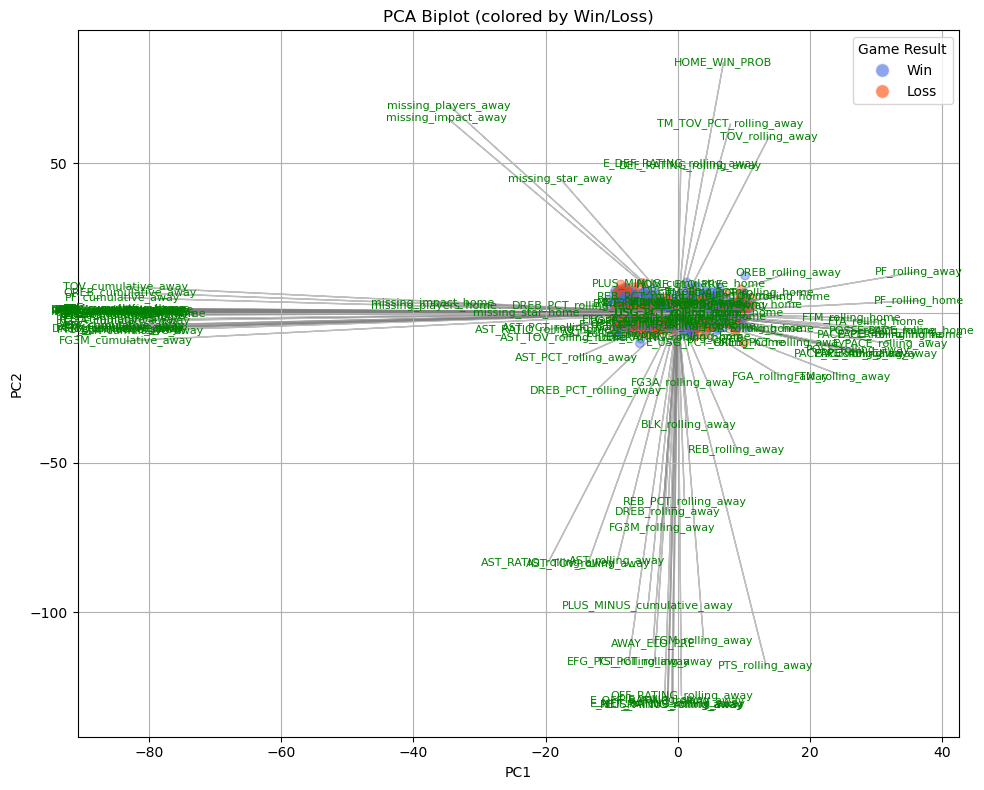

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Project the training data onto the first two principal components
pc1 = X_train_pca[:, 0]
pc2 = X_train_pca[:, 1]

# Color by win/loss
colors = np.where(y_train.values == 1, 'royalblue', 'orangered')
labels = np.where(y_train.values == 1, 'Win', 'Loss')

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pc1, pc2, c=colors, alpha=0.4, label=None)

# Plot feature vectors (loadings)
scale = 499
for i, feature in enumerate(X_train.columns):
    plt.arrow(0, 0, 
              loadings.iloc[i, 0]*scale,  # scale for visibility
              loadings.iloc[i, 1]*scale, 
              color='gray', alpha=0.5)
    plt.text(loadings.iloc[i, 0]*scale, 
             loadings.iloc[i, 1]*scale, 
             feature, color='green', ha='center', va='center', fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot (colored by Win/Loss)')
plt.grid(True)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Win', markerfacecolor='royalblue', markersize=10, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Loss', markerfacecolor='orangered', markersize=10, alpha=0.6)
]
plt.legend(handles=legend_elements, title='Game Result')
plt.tight_layout()
plt.show()

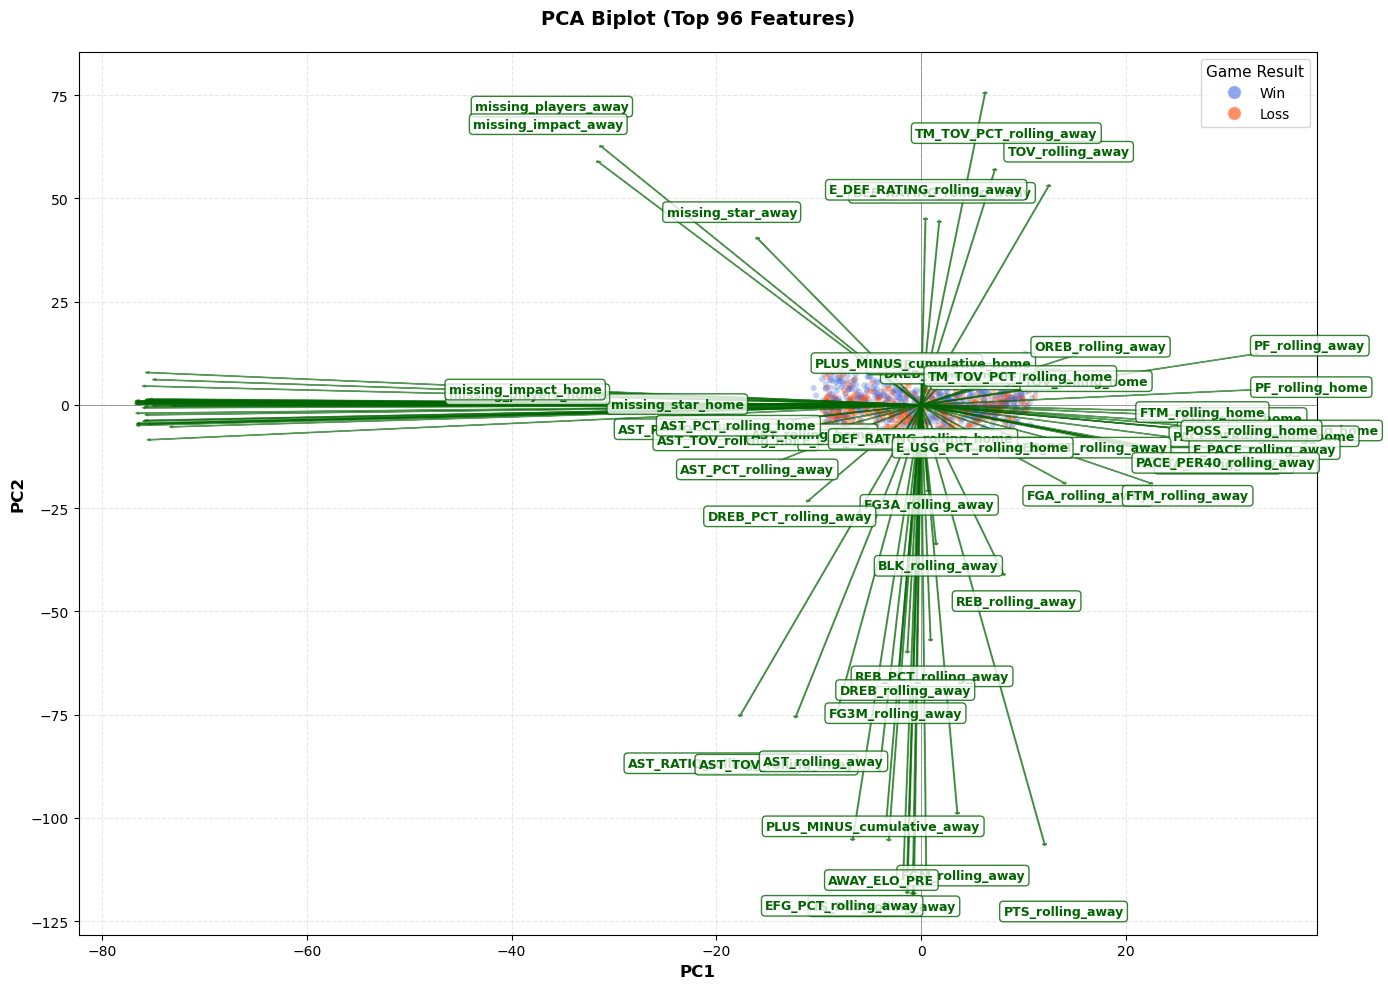

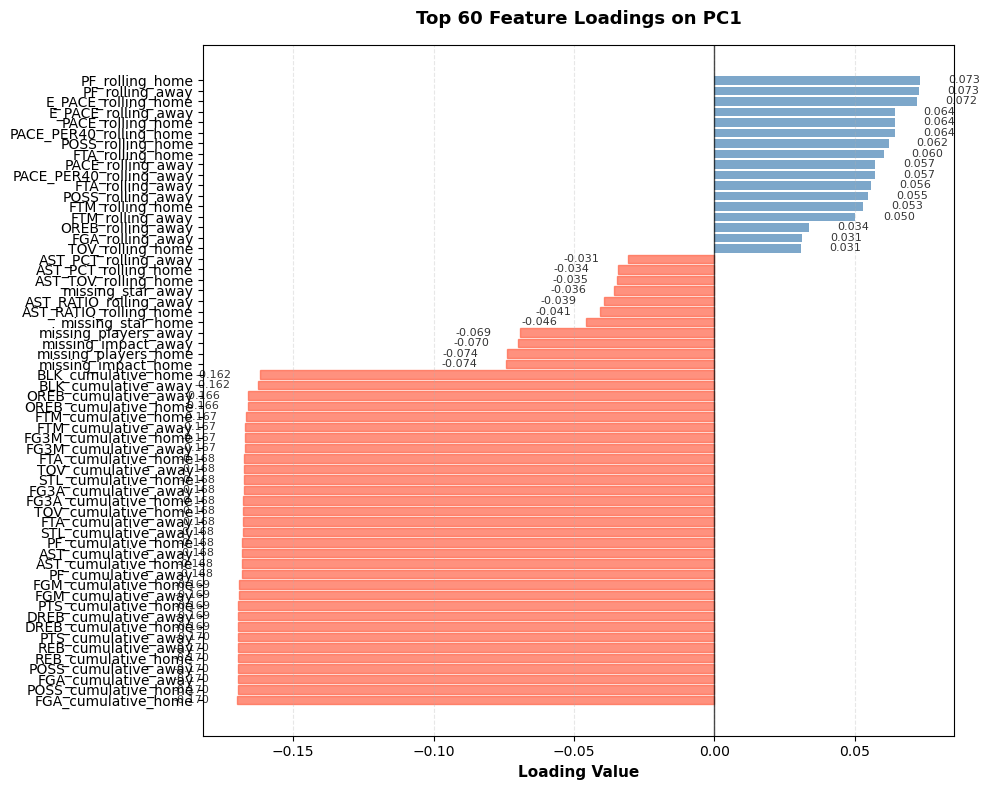

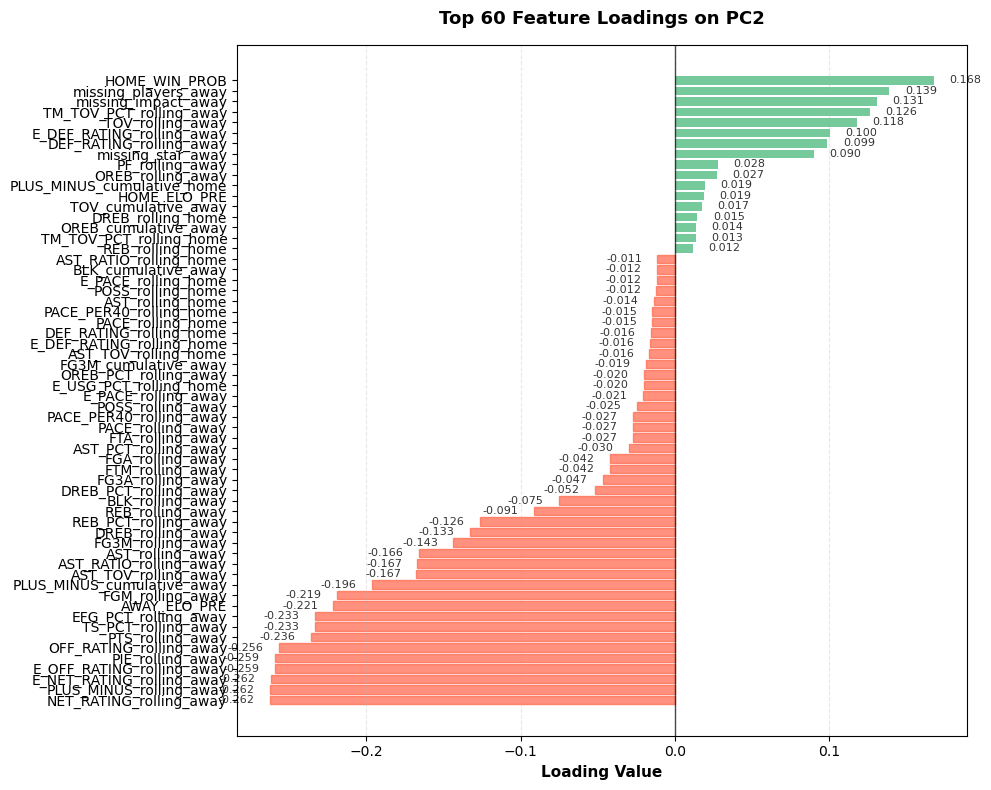

In [38]:
"""
Improved PCA Visualization - Three Separate Plots
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

def create_biplot(X_train_pca, y_train, loadings, X_train, n_top_features=50):
    """
    Creates a cleaner biplot showing only the most important features.

    Parameters:
    -----------
    X_train_pca : array, shape (n_samples, n_components)
        PCA-transformed training data
    y_train : array/Series, shape (n_samples,)
        Target labels (1 for win, 0 for loss)
    loadings : DataFrame, shape (n_features, n_components)
        PCA loadings (components)
    X_train : DataFrame, shape (n_samples, n_features)
        Original training features (for column names)
    n_top_features : int, default=10
        Number of top features to show arrows for
    """
    pc1 = X_train_pca[:, 0]
    pc2 = X_train_pca[:, 1]
    colors = np.where(y_train.values == 1, 'royalblue', 'orangered')

    # Find top contributors to PC1 and PC2
    load = loadings.iloc[:, :2].copy()

    # Get top N features by absolute loading for each PC
    top_pc1 = load.iloc[:, 0].abs().nlargest(n_top_features).index
    top_pc2 = load.iloc[:, 1].abs().nlargest(n_top_features).index
    top_features = list(set(top_pc1) | set(top_pc2))  # Union of both

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 10))

    # Scatter plot of scores
    ax.scatter(pc1, pc2, c=colors, alpha=0.3, s=20, edgecolors='none')

    # Determine scaling factor for arrows based on the data range
    data_range = max(pc1.max() - pc1.min(), pc2.max() - pc2.min())
    arrow_scale = data_range * 20  # Arrows will be ~40% of the plot size

    # Plot arrows and labels only for top features
    for feature in top_features:
        idx = X_train.columns.get_loc(feature)
        dx = load.iloc[idx, 0] * arrow_scale
        dy = load.iloc[idx, 1] * arrow_scale

        # Draw arrow
        ax.arrow(0, 0, dx, dy,
                color='darkgreen', alpha=0.6,
                width=data_range*0.003,
                head_width=data_range*0.02,
                head_length=data_range*0.015,
                length_includes_head=True, zorder=5)

        # Add label at arrow tip with smart positioning
        label_offset = 1.15
        ax.annotate(feature,
                   xy=(dx*label_offset, dy*label_offset),
                   fontsize=9, color='darkgreen',
                   weight='bold',
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='white',
                           edgecolor='darkgreen',
                           alpha=0.8),
                   zorder=10)

    ax.set_xlabel('PC1', fontsize=12, weight='bold')
    ax.set_ylabel('PC2', fontsize=12, weight='bold')
    ax.set_title(f'PCA Biplot (Top {len(top_features)} Features)',
                fontsize=14, weight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.5)

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Win',
              markerfacecolor='royalblue', markersize=10, alpha=0.6),
        Line2D([0], [0], marker='o', color='w', label='Loss',
              markerfacecolor='orangered', markersize=10, alpha=0.6)
    ]
    ax.legend(handles=legend_elements, title='Game Result',
             loc='best', fontsize=10, title_fontsize=11)

    plt.tight_layout()
    return fig


def create_loadings_plot(loadings, pc_num=0, top_n=50, color='steelblue'):
    """
    Creates a clean horizontal bar plot for PC loadings.

    Parameters:
    -----------
    loadings : DataFrame, shape (n_features, n_components)
        PCA loadings (components)
    pc_num : int, default=0
        Which PC to plot (0 for PC1, 1 for PC2, etc.)
    top_n : int, default=20
        Number of top features to display
    color : str, default='steelblue'
        Bar color
    """
    pc_loadings = loadings.iloc[:, pc_num].copy()

    # Get top N by absolute value
    top_loadings = pc_loadings.reindex(
        pc_loadings.abs().nlargest(top_n).index
    ).sort_values()

    fig, ax = plt.subplots(figsize=(10, 8))

    # Create horizontal bar chart
    bars = ax.barh(range(len(top_loadings)), top_loadings.values, color=color, alpha=0.7)

    # Color bars by sign
    for i, (bar, val) in enumerate(zip(bars, top_loadings.values)):
        if val < 0:
            bar.set_color('tomato')

    ax.set_yticks(range(len(top_loadings)))
    ax.set_yticklabels(top_loadings.index, fontsize=10)
    ax.set_xlabel(f'Loading Value', fontsize=11, weight='bold')
    ax.set_title(f'Top {top_n} Feature Loadings on PC{pc_num+1}',
                fontsize=13, weight='bold', pad=15)
    ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.7)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_loadings.values)):
        label_x = val + (0.01 if val > 0 else -0.01)
        ha = 'left' if val > 0 else 'right'
        ax.text(label_x, i, f'{val:.3f}',
               va='center', ha=ha, fontsize=8, alpha=0.8)

    plt.tight_layout()
    return fig


# Plot 1: Biplot with top features
fig1 = create_biplot(X_train_pca, y_train, loadings, X_train,
                    n_top_features=60)
plt.show()

# Plot 2: PC1 loadings
fig2 = create_loadings_plot(loadings, pc_num=0, top_n=60,
                            color='steelblue')
plt.show()

# Plot 3: PC2 loadings
fig3 = create_loadings_plot(loadings, pc_num=1, top_n=60,
                            color='mediumseagreen')
plt.show()

In [23]:
# Show the loadings (feature weights) for PC1 and PC2
loadings[['PC1', 'PC2']].sort_values(by='PC1', ascending=False)

,PC1,PC2
PF_rolling_home,0.073273,0.008279
PF_rolling_away,0.072991,0.027576
E_PACE_rolling_home,0.072197,-0.011892
E_PACE_rolling_away,0.064495,-0.020568
PACE_rolling_home,0.064401,-0.014589
...,...,...
REB_cumulative_home,-0.169684,0.001525
POSS_cumulative_away,-0.169764,0.001523
FGA_cumulative_away,-0.169775,0.002172
POSS_cumulative_home,-0.169792,0.000697


In [29]:
# Sort by absolute value of loadings for PC1
loadings[['PC1', 'PC2']].reindex(loadings['PC1'].abs().sort_values(ascending=False).index)

,PC1,PC2
FGA_cumulative_home,-0.169803,0.000584
POSS_cumulative_home,-0.169792,0.000697
FGA_cumulative_away,-0.169775,0.002172
POSS_cumulative_away,-0.169764,0.001523
REB_cumulative_home,-0.169684,0.001525
...,...,...
HOME_ELO_PRE,0.000642,0.018831
PLUS_MINUS_cumulative_home,0.000424,0.019470
DEF_RATING_rolling_home,0.000359,-0.015820
USG_PCT_rolling_home,0.000000,-0.000000
